# CQ - FASE RELATIVA - ANÁLISE DE PROBALIDADES

QUICKST - Carregamento

In [3]:

!pip install qiskit -U
!pip install qiskit_aer -U
!pip install qiskit-ibm-runtime -U

!pip install matplotlib #criação de graficos
!pip install pylatexenc #manipula códigos em latex

import qiskit
qiskit.__version__

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 96.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 368.7/368.7 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 10.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 11.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=13d7a96668bdf97c49f212701f1b241de9369ed356e7942b4eca3f07ebbced0e
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178

'2.2.1'

In [4]:
## Backend fake // ambiente fisíco que gerência a manipulação dos circuitos quânticos
from qiskit_ibm_runtime.fake_provider import FakeBrisbane
backend = FakeBrisbane() # FakeBrisbane(): 127 qubits. Mais fake backends: 'https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/fake-provider'


In [5]:
# Qiskit: métodos básicos

from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister

from qiskit import transpile #processo de reescrever um circuito quântico

from qiskit.visualization import plot_histogram, array_to_latex, plot_state_city



# MÉTODOS PRIMITIVOS

In [6]:
def qiskit_sampler(circuito_com_medidas, shots = None, backend = None):
    '''
    Método para executar o Sampler
    >>> O Sampler realiza medidas em circuitos quânticos e retorna a contagem de qubits.
        A partir dos resultados do Sampler, podemos estimar as probabilidade de cada resultado.

    Input:
        circuito : circuito quântico que prepara um estado de qubits
        backend  : backend para rodar o Sampler

    Saída:
        resultado do Sampler

    Observação: os resultados do Sampler são rotulados pelo nomes dos registros clássicos.
                Para um circuito com medidas definidas por 'measure_all', o rótulo é 'meas'.
                Para circuitos com medidas definidas de início sem denominação explícita,
                os rótulos são 'c', 'c1', 'c2', etc.

    Tutorial do SamplerV2: https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/sampler-v2
    '''

    # Importação de métodos e backend

    from qiskit_ibm_runtime import SamplerV2 as Sampler
      # Importação de métodos e backend

    from qiskit_ibm_runtime import SamplerV2 as Sampler

    if backend is None:
        from qiskit_ibm_runtime.fake_provider import FakeBrisbane
        backend = FakeBrisbane()
    else:
        backend = backend

    from qiskit.transpiler import generate_preset_pass_manager
    pm = generate_preset_pass_manager(optimization_level=2, backend = backend)

    # Transpilação: mistura de traduzir e compilar, transforma um circutio escritos em linguagem
    # de alto nível em um circuito otimizado para um processador quântico (QPU) real ou simulado.

    isa_circuitos = pm.run(circuito_com_medidas)

    if shots is None:
        shots = 2**10
    else:
        shots = shots

    sampler = Sampler(backend)
    job = sampler.run([(isa_circuitos, )], shots = shots)
    result = job.result()
    counts = result[0].data['c'].get_counts()

    return counts, result

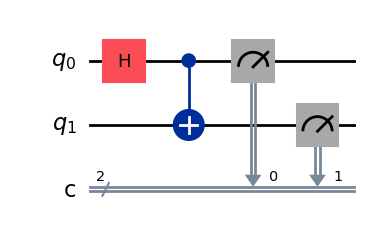

({'11': 496, '00': 498, '01': 25, '10': 5},
 PrimitiveResult([SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=1024, num_bits=2>)), metadata={'shots': 1024, 'circuit_metadata': {}})], metadata={'version': 2}))

In [7]:
'''
Teste
'''

qc = QuantumCircuit(2,2)
qc.h(0)
qc.cx(0,1)
qc.measure([0,1],[0,1])
#print(qc)
display(qc.draw('mpl'))

resultado = qiskit_sampler(qc)
resultado

In [8]:
def qiskit_estimator(circuito_sem_medidas, hamiltoniano, precisao = None, backend = None):
    '''
    Método para executar o Estimator
    >>> O Estimator estima valores esperados de circuitos e observáveis.

    Input:
        circuito : circuito quântico que prepara um estado de qubits
        hamiltoniano (SparsePauliOp): hamiltoniano a ser medido
        precisao (float): precisão do resultado
        backend  : backend para rodar o Estimator

    Saída:
        resultado do Estimator

    Tutorial do EstimatorV2: https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/estimator-v2
    '''

    # Importação de métodos e backend

    from qiskit_ibm_runtime import EstimatorV2 as Estimator
    from qiskit.transpiler import generate_preset_pass_manager

    # Use the existing service object
    # service = QiskitRuntimeService()
    if backend is None:
        from qiskit_ibm_runtime.fake_provider import FakeBrisbane
        backend = FakeBrisbane()
    else:
       backend = backend

    if precisao is None:
        precisao = 2**(-10)
    else:
        precisao = precisao

    # Transpilação

    pm = generate_preset_pass_manager(backend = backend, optimization_level=1)
    isa_circuito = pm.run(circuito_sem_medidas)
    isa_hamiltoniano = hamiltoniano.apply_layout(isa_circuito.layout)

    # Estimator:

    estimator = Estimator(mode=backend)

    # Job
    job = estimator.run([(isa_circuito, isa_hamiltoniano, )])
    pub_result = job.result()[0]

    return pub_result.data.evs


In [10]:
'''
Teste
'''


qc = QuantumCircuit(2,2)
qc.h(0)
qc.cx(0,1)
print(qc)

from qiskit.quantum_info import SparsePauliOp
hamiltoniano = SparsePauliOp.from_list([("II", 1), ("IZ", 2), ("XI", 3)])
print(f"Hamiltoniano: {hamiltoniano}")

precisao = 2**(-10)
print(f"Precisão: {precisao}")

resultado = qiskit_estimator(qc, hamiltoniano, precisao)
display(f"Valor esperado: {resultado}")

     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘
c: 2/══════════
               
Hamiltoniano: SparsePauliOp(['II', 'IZ', 'XI'],
              coeffs=[1.+0.j, 2.+0.j, 3.+0.j])
Precisão: 0.0009765625


'Valor esperado: 1.0322265625'

# EXPERIMENTO COM FASE RELATIVA

#MEDIDA |Ψ(0)> NA BASE COMPUTACIONAL

-> o resultado não depende de TETA

Circuito que prepara o estado | psi >:


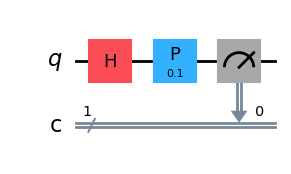

In [13]:


# Experimentos com o Sampler: Medida na base { |0>, |1>}

import numpy as np

th = 0.1#np.pi/2
qc = QuantumCircuit(1,1)
qc.h(0)
qc.p(th,0)
qc.measure([0],[0])

print("Circuito que prepara o estado | psi >:")
display(qc.draw('mpl'))

In [ ]:
# Experimento
medida = qiskit_sampler(qc, shots = 2**8, backend = FakeBrisbane())
print(f"Medida: {medida}")

resultado = medida[0]
print(f"Resultado: {resultado}")

prob_0 = resultado.get('0', 0) / sum(resultado.values())
print(f"Probabilidade de medir |0>: {prob_0}")
prob_1 = resultado.get('1', 0) / sum(resultado.values())
print(f"Probabilidade de medir |1>: {prob_1}")
#

plot_histogram(resultado)

In [14]:

# Função

def probabilidadeZ_psi(th):
    qc = QuantumCircuit(1,1)
    qc.h(0)
    qc.p(th,0)
    qc.measure([0],[0])

    medida = qiskit_sampler(qc, shots = 2**10, backend = FakeBrisbane())

    resultado = medida[0]
    prob_0 = resultado.get('0', 0) / sum(resultado.values())
    prob_1 = resultado.get('1', 0) / sum(resultado.values())

    return (prob_0,prob_1)

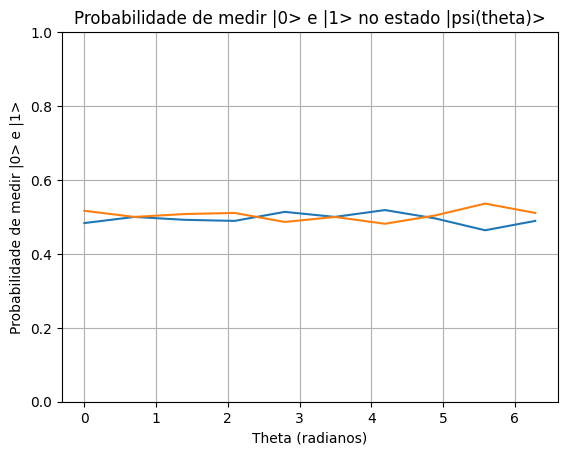

In [15]:


import matplotlib.pyplot as plt
import numpy as np

# Create a range of theta values
theta_values = np.linspace(0, 2 * np.pi, 10)

# Calculate the probability of measuring |0> for each theta value
prob_0, prob_1 = zip(*[probabilidadeZ_psi(theta) for theta in theta_values])

# Plot the results
plt.plot(theta_values, prob_0)
plt.plot(theta_values, prob_1)
plt.ylim(0, 1)
plt.xlabel("Theta (radianos)")
plt.ylabel("Probabilidade de medir |0> e |1>")
plt.title("Probabilidade de medir |0> e |1> no estado |psi(theta)>")
plt.grid(True)
plt.show()


# MEDIDAS DE |PSI(0)> NA BASE DE X, {|+ > , | - >}

-> O resultado depende de 0.

Circuito que prepara o estado | psi >:


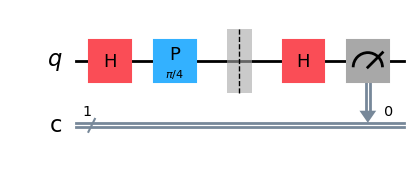

In [16]:
# Experimentos com o Sampler: Medida na base { |+>, |-> }


import numpy as np

th = np.pi/4
qc = QuantumCircuit(1,1)
qc.h(0)
qc.p(th,0)
qc.barrier()
qc.h(0) # <-- Porta para medir na base {|+>,|->}
qc.measure([0],[0])

print("Circuito que prepara o estado | psi >:")
display(qc.draw('mpl'))

Medida: ({'0': 219, '1': 37}, PrimitiveResult([SamplerPubResult(data=DataBin(c=BitArray(<shape=(), num_shots=256, num_bits=1>)), metadata={'shots': 256, 'circuit_metadata': {}})], metadata={'version': 2}))
Resultado: {'0': 219, '1': 37}
Probabilidade de medir |0>: 0.85546875
Probabilidade de medir |1>: 0.14453125


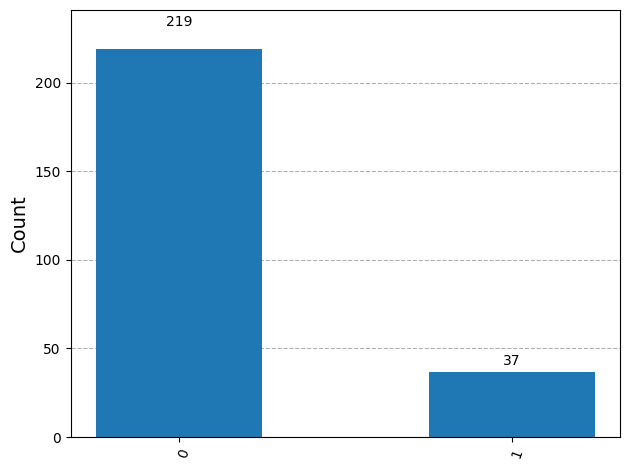

In [17]:
# Experimento
medida = qiskit_sampler(qc, shots = 2**8, backend = FakeBrisbane())
print(f"Medida: {medida}")

resultado = medida[0]
print(f"Resultado: {resultado}")

prob_plus = resultado.get('0', 0) / sum(resultado.values())
print(f"Probabilidade de medir |0>: {prob_plus}")
prob_minus = resultado.get('1', 0) / sum(resultado.values())
print(f"Probabilidade de medir |1>: {prob_minus}")
#

plot_histogram(resultado)

In [18]:
# Função

def probabilidadeX_psi(th):
    qc = QuantumCircuit(1,1)
    qc.h(0)
    qc.p(th,0)
    qc.h(0)
    qc.measure([0],[0])

    medida = qiskit_sampler(qc, shots = 2**10, backend = FakeBrisbane())

    resultado = medida[0]
    prob_plus = resultado.get('0', 0) / sum(resultado.values())
    prob_minus = resultado.get('1', 0) / sum(resultado.values())

    return (prob_plus,prob_minus)

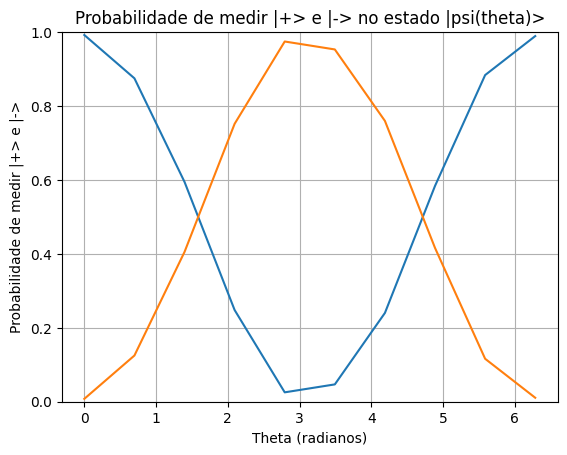

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Create a range of theta values
theta_values = np.linspace(0, 2 * np.pi, 10)

# Calculate the probability of measuring |0> for each theta value
prob_plus, prob_minus = zip(*[probabilidadeX_psi(theta) for theta in theta_values])

# Plot the results
plt.plot(theta_values, prob_plus)
plt.plot(theta_values, prob_minus)
plt.ylim(0, 1)
plt.xlabel("Theta (radianos)")
plt.ylabel("Probabilidade de medir |+> e |->")
plt.title("Probabilidade de medir |+> e |-> no estado |psi(theta)>")
plt.grid(True)
plt.show()